# Homework 1 — Single-Qubit States, Gates and Measurement
**Notebook:** State preparation with $U_3$/H/Rz gates; measurement in computational and superposition bases; 2-qubit entanglement via Schmidt decomposition

## Context

This homework covers the foundations of single-qubit quantum mechanics in Qiskit:

- **Problem 1:** Prepare $|\psi\rangle = \sin\theta|0\rangle + e^{i\varphi}\cos\theta|1\rangle$ and measure the phase $\varphi$ via basis rotation
- **Problem 2:** Decompose the same state preparation using only $H$, $R_z$, and standard gates
- **Problem 3:** Prove gate identities ($HXH=Z$, symmetry of CZ, etc.)
- **Problem 4:** Sequential vs simultaneous measurement — prove equivalence via conditional probabilities

### Key concept: measurement bases
- **Computational basis** ($Z$-basis): measure directly → probabilities give $|\alpha|^2$, $|\beta|^2$
- **Superposition basis** ($X$-basis): apply $H$ then measure → reveals relative phase $\varphi$

### Key concept: $U_3$ / $U$ gate
The general single-qubit rotation: $U(\theta,\phi,\lambda) = \begin{pmatrix}\cos\frac{\theta}{2} & -e^{i\lambda}\sin\frac{\theta}{2} \\ e^{i\phi}\sin\frac{\theta}{2} & e^{i(\phi+\lambda)}\cos\frac{\theta}{2}\end{pmatrix}$

(Renamed from $U_3$ to $U$ in Qiskit 1.x)

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

# pip install qiskit qiskit-aer qiskit-ibm-runtime
import qiskit as qk
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from numpy import pi
import numpy as np

In [ ]:
# --- IBM Quantum hardware setup ---
# Run once to save credentials:
#   from qiskit_ibm_runtime import QiskitRuntimeService
#   QiskitRuntimeService.save_account(channel='ibm_quantum', token='YOUR_TOKEN', overwrite=True)
from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService(channel='ibm_quantum', token=os.environ.get('IBM_QUANTUM_TOKEN'))
print("IBM Quantum: uncomment the line above after setting IBM_QUANTUM_TOKEN in .env")

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

qreg_q = QuantumRegister(3, 'q')
creg_c = ClassicalRegister(3, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)

# Prepare |psi> = sin(theta)|0> + exp(i*phi)*cos(theta)|1> with theta=phi=pi/3
# U(theta, phi, lambda) gate parameters for this state:
#   theta  = 2*pi/3  — polar angle (controls |0>/|1> amplitudes via cos/sin of theta/2)
#   phi    = pi/3    — azimuthal phase on |1> component (the phase phi we want to measure)
#   lambda = -pi/3   — additional phase on |0> component (chosen to match the U3 matrix form)
# u3 renamed to u in Qiskit 1.x (same parameters: theta, phi, lambda)
circuit.u(2 * pi / 3, pi / 3, -pi / 3, qreg_q[0])

# measureX: apply H before measuring → rotates X-basis to Z-basis
# This is measurement in the superposition (X) basis; reveals the relative phase phi
measureX = qk.QuantumCircuit(qreg_q, creg_c)
measureX.h(qreg_q)             # H maps |+>→|0>, |->→|1>, making phase info visible
measureX.measure(qreg_q[0], creg_c[0])

# measureZ: measure directly in the computational (Z) basis
# Gives probabilities sin^2(theta) for |0> and cos^2(theta) for |1> → determines theta
measureZ = qk.QuantumCircuit(qreg_q, creg_c)
measureZ.measure(qreg_q[0], creg_c[0])

# Compose state-prep circuit with each measurement circuit
testZ = circuit + measureZ   # Z-basis measurement: extracts theta
testX = circuit + measureX   # X-basis measurement: extracts phi given theta

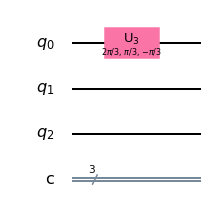

In [40]:
circuit.draw(output='mpl')

In [ ]:
# Run both measurement circuits on the Aer simulator with 1024 shots
# testZ measures in the Z (computational) basis; testX measures in the X (superposition) basis
backend = AerSimulator()
jobIBM = backend.run(transpile([testZ, testX], backend), shots=1024)
resultSim = jobIBM.result()

In [ ]:
from qiskit.visualization import plot_histogram
plot_histogram([resultSim.get_counts(testZ), resultSim.get_counts(testX)])

By measuring in usual basis we determine $\cos\theta = 1/2$ so that $\theta=\pi/3$. By measuring in suparposition basis 
we get $\sin(2\theta)\cos\varphi = -  0.418 \approx - \sqrt 3/4$ which means $\varphi = \pi/3$ 

In [ ]:
# Run on real IBM device (requires account setup above):
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
# sampler = Sampler(backend_real)
# job = sampler.run([transpile(testZ, backend_real), transpile(testX, backend_real)], shots=1024)
# counts_Z = job.result()[0].data.c.get_counts()
# counts_X = job.result()[1].data.c.get_counts()
resultExp = resultSim   # use simulator as stand-in
print("Note: using simulator results. Uncomment above for real hardware.")

In [ ]:
from qiskit.visualization import plot_histogram
plot_histogram([resultExp.get_counts(testZ), resultSim.get_counts(testZ)],
               legend=['Real device (or sim)', 'Simulator'])

In [ ]:
qreg_q1 = QuantumRegister(3, 'q')
creg_c1 = ClassicalRegister(3, 'c')
circuit1 = QuantumCircuit(qreg_q1, creg_c1)

# Problem 2: Decompose U(theta, phi, lambda) into H and Rz gates only.
# The identity used is: U(-pi/3, pi+pi/3, 0) = Rz(phi-pi/2) H Rz(2*theta+pi) H
# Step-by-step derivation:
#   H|0> = (|0>+|1>)/sqrt(2)
#   Rz(2*theta+pi) H|0> = (|0> - exp(2i*theta)|1>)/sqrt(2)
#   H Rz(2*theta+pi) H|0> = -i*exp(i*theta)*(sin(theta)|0> + i*cos(theta)|1>)
#   Rz(phi-pi/2) H Rz(2*theta+pi) H|0> = -i*exp(i*theta)*(sin(theta)|0> + exp(i*phi)*cos(theta)|1>)
# This matches the target state up to a global phase.
circuit1.rz(pi / 3 + pi / 2, qreg_q1[0])       # Rz(phi - pi/2): sets azimuthal phase phi = pi/3
circuit1.h(qreg_q1[0])                           # H: first Hadamard in H-Rz-H sandwich
circuit1.rz(pi * 2 / 3, qreg_q1[0])             # Rz(2*theta): controls the polar angle theta = pi/3
circuit1.h(qreg_q1[0])                           # H: second Hadamard completes the X-rotation
circuit1.rz(-(pi / 3 + pi / 2), qreg_q1[0])     # Rz(-(phi - pi/2)): corrects the final phase

# X-basis measurement: apply H then measure → extracts relative phase phi
measureX1 = qk.QuantumCircuit(qreg_q1, creg_c1)
measureX1.h(qreg_q1)
measureX1.measure(qreg_q1[0], creg_c1[0])

# Z-basis measurement: measure directly → extracts amplitude angle theta
measureZ1 = qk.QuantumCircuit(qreg_q1, creg_c1)
measureZ1.measure(qreg_q1[0], creg_c1[0])

testZ1 = circuit1 + measureZ1   # Z-basis: should give ~75% |0>, ~25% |1> (sin^2(pi/3), cos^2(pi/3))
testX1 = circuit1 + measureX1   # X-basis: should give ~71.6% |0>, ~28.4% |1> (phase-dependent)

In [ ]:
backend = AerSimulator()
jobIBM1 = backend.run(transpile([testZ1, testX1], backend), shots=1024)
resultSim1 = jobIBM1.result()

In [ ]:
from qiskit.visualization import plot_histogram
plot_histogram([resultSim1.get_counts(testZ1), resultSim1.get_counts(testX1)])

In [17]:
backend=Aer.get_backend('qasm_simulator')
jobIBM1=qk.execute(circuit1,backend=backend,shots=1024)
resultSim1=jobIBM1.result()

In [ ]:
# Compare u gate vs H-Rz-H decomposition (simulator)
from qiskit.visualization import plot_histogram
plot_histogram([resultSim.get_counts(testZ), resultSim1.get_counts(testZ1)],
               legend=['u gate (sim)', 'H-Rz-H decomposition (sim)'])

# Real hardware comparison (uncomment when IBM Quantum account is available):
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
# sampler = Sampler(backend_real)
# job = sampler.run([transpile(testZ, backend_real), transpile(testZ1, backend_real)], shots=1024)
# counts_u = job.result()[0].data.c.get_counts()
# counts_rz = job.result()[1].data.c.get_counts()
# plot_histogram([counts_u, counts_rz], legend=['u gate', 'H-Rz-H decomposition'])

In [ ]:
from qiskit.visualization import plot_histogram
plot_histogram([resultExp.get_counts(circuit),resultSim.get_counts(circuit)])

In [8]:
my_provider = IBMQ.get_provider()
my_provider.backends()

[<IBMQSimulator('ibmq_qasm_simulator') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmqx2') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_16_melbourne') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_vigo') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_ourense') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_valencia') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_armonk') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_santiago') from IBMQ(hub='ibm-q', group='open', project='main')>]

In [39]:
my_provider = IBMQ.get_provider(hub='ibm-q')
my_provider.backends()

from qiskit.providers.ibmq import least_busy

small_devices = my_provider.backends(filters=lambda x: x.configuration().n_qubits == 5
                                   and not x.configuration().simulator)
least_busy(small_devices)

<IBMQBackend('ibmqx2') from IBMQ(hub='ibm-q', group='open', project='main')>

In [6]:
my_provider = IBMQ.get_provider()
#backend  = my_provider.get_backend('ibmq_ourense')
#backend  = my_provider.get_backend('ibmq_qasm_simulator')
#backend=Aer.get_backend('qasm_simulator')